In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
# --- Configuration ---
ROOT_DIR = Path("Fig4") if Path("Fig4").exists() else Path(".")
DATA_DIR = ROOT_DIR / "input/ragasa/uv_rmse"
OUT_DIR = ROOT_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["pangu", "graphcast", "fengwu", "fuxi", "aurora"]
LEADS = ["24h", "48h"]

START_TIME = pd.Timestamp("2025-09-23 10:00", tz="UTC")
END_TIME = pd.Timestamp("2025-09-24 10:00", tz="UTC")
WINDOW_TAG = f"{START_TIME:%Y%m%d-%H}_to_{END_TIME:%Y%m%d-%H}"

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 16,
    }
)

MODEL_STYLES = {
    "pangu": {"label": "Pangu", "color": "#f58518"},
    "graphcast": {"label": "GraphCast", "color": "#54a24b"},
    "fengwu": {"label": "FengWu", "color": "#e45756"},
    "fuxi": {"label": "FuXi", "color": "#72b7b2"},
    "aurora": {"label": "Aurora", "color": "#b279a2"},
}


# --- Data loading ---
def read_uv_obs(component: str) -> pd.DataFrame:
    path = DATA_DIR / f"results_uv_obs/{component}_obs.csv"
    return pd.read_csv(path)


def read_uv_sim(component: str, model: str, lead: str) -> pd.DataFrame:
    path = DATA_DIR / f"results_uv_sim/{model}_{component}_sim_{lead}.csv"
    return pd.read_csv(path)


u_obs = read_uv_obs("u")
v_obs = read_uv_obs("v")

u_sim = {lead: {model: read_uv_sim("u", model, lead) for model in MODELS} for lead in LEADS}
v_sim = {lead: {model: read_uv_sim("v", model, lead) for model in MODELS} for lead in LEADS}

# Backward-compatible names used by later cells
u_sim_24h, u_sim_48h = u_sim["24h"], u_sim["48h"]
v_sim_24h, v_sim_48h = v_sim["24h"], v_sim["48h"]

STATIONS = [c for c in u_obs.columns if c != "timestamp_utc"]

print("Loaded U/V obs + model simulations")
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
print("Models:", ", ".join(MODELS))
print("Leads:", ", ".join(LEADS))
print("Stations:", len(STATIONS))
print("Window:", START_TIME, "to", END_TIME)

Loaded U/V obs + model simulations
Data dir: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig4\input\ragasa\uv_rmse
Output dir: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig4\output
Models: pangu, graphcast, fengwu, fuxi, aurora
Leads: 24h, 48h
Stations: 30
Window: 2025-09-23 10:00:00+00:00 to 2025-09-24 10:00:00+00:00


In [3]:
# --- Helpers (parsing, RMSE, plotting) ---
TS_COL = "timestamp_utc"
TS_FORMAT = "%Y%m%d %H%M"


def parse_and_subset(
    df: pd.DataFrame,
    stations: list[str],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    ts_col: str = TS_COL,
    ts_format: str = TS_FORMAT,
) -> pd.DataFrame:
    """Parse timestamps, subset to time window, coerce station columns to numeric."""
    required_cols = [ts_col, *stations]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[required_cols].copy()
    data[ts_col] = pd.to_datetime(data[ts_col], format=ts_format, utc=True, errors="coerce")
    data = data.dropna(subset=[ts_col])

    mask = (data[ts_col] >= start_time) & (data[ts_col] <= end_time)
    data = data.loc[mask].sort_values(ts_col).reset_index(drop=True)

    data[stations] = data[stations].apply(pd.to_numeric, errors="coerce")
    return data


def rmse_by_station(
    obs_df: pd.DataFrame,
    sim_df: pd.DataFrame,
    stations: list[str],
    ts_col: str = TS_COL,
) -> pd.Series:
    """Scalar RMSE per station: sqrt(mean((sim-obs)^2)) over common timestamps."""
    obs = obs_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    sim = sim_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)

    common = obs.index.intersection(sim.index)
    if len(common) == 0:
        return pd.Series(index=stations, dtype=float, name="rmse")

    diff = sim.loc[common, stations] - obs.loc[common, stations]
    rmse = np.sqrt((diff**2).mean(axis=0, skipna=True))
    rmse.name = "rmse"
    return rmse


def vector_rmse_by_station(
    obs_u_df: pd.DataFrame,
    obs_v_df: pd.DataFrame,
    sim_u_df: pd.DataFrame,
    sim_v_df: pd.DataFrame,
    stations: list[str],
    ts_col: str = TS_COL,
) -> pd.Series:
    """Vector RMSE per station: sqrt(mean(du^2 + dv^2)) over common timestamps."""
    obs_u = obs_u_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    obs_v = obs_v_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_u = sim_u_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_v = sim_v_df[[ts_col, *stations]].dropna(subset=[ts_col]).set_index(ts_col)

    common = obs_u.index
    common = common.intersection(obs_v.index)
    common = common.intersection(sim_u.index)
    common = common.intersection(sim_v.index)
    if len(common) == 0:
        return pd.Series(index=stations, dtype=float, name="rmse")

    du = sim_u.loc[common, stations] - obs_u.loc[common, stations]
    dv = sim_v.loc[common, stations] - obs_v.loc[common, stations]

    rmse = np.sqrt((du**2 + dv**2).mean(axis=0, skipna=True))
    rmse.name = "rmse"
    return rmse


def compute_scalar_rmse_long(
    obs_raw: pd.DataFrame,
    sim_by_lead: dict[str, dict[str, pd.DataFrame]],
    component: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (rmse_long, align_df) for a scalar component (u or v)."""
    obs = parse_and_subset(obs_raw, STATIONS, START_TIME, END_TIME)
    obs_idx = set(obs[TS_COL])

    records: list[dict] = []
    align: list[dict] = []
    for lead in LEADS:
        for model in MODELS:
            sim = parse_and_subset(sim_by_lead[lead][model], STATIONS, START_TIME, END_TIME)
            sim_idx = set(sim[TS_COL])
            align.append(
                {
                    "component": component,
                    "lead": lead,
                    "model": model,
                    "n_obs": len(obs_idx),
                    "n_sim": len(sim_idx),
                    "n_common": len(obs_idx.intersection(sim_idx)),
                }
            )

            rmse_s = rmse_by_station(obs, sim, STATIONS)
            records.extend(
                {
                    "component": component,
                    "lead": lead,
                    "model": model,
                    "station": st,
                    "rmse": float(val) if pd.notna(val) else np.nan,
                }
                for st, val in rmse_s.items()
            )

    return pd.DataFrame(records), pd.DataFrame(align)


def compute_vector_rmse_long(
    obs_u_raw: pd.DataFrame,
    obs_v_raw: pd.DataFrame,
    u_sim_by_lead: dict[str, dict[str, pd.DataFrame]],
    v_sim_by_lead: dict[str, dict[str, pd.DataFrame]],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (rmse_long, align_df) for vector wind RMSE using both u and v."""
    obs_u = parse_and_subset(obs_u_raw, STATIONS, START_TIME, END_TIME)
    obs_v = parse_and_subset(obs_v_raw, STATIONS, START_TIME, END_TIME)
    obs_common = set(obs_u[TS_COL]).intersection(set(obs_v[TS_COL]))

    records: list[dict] = []
    align: list[dict] = []
    for lead in LEADS:
        for model in MODELS:
            sim_u = parse_and_subset(u_sim_by_lead[lead][model], STATIONS, START_TIME, END_TIME)
            sim_v = parse_and_subset(v_sim_by_lead[lead][model], STATIONS, START_TIME, END_TIME)

            sim_common = set(sim_u[TS_COL]).intersection(set(sim_v[TS_COL]))
            common = obs_common.intersection(sim_common)
            align.append({"component": "vector", "lead": lead, "model": model, "n_common": len(common)})

            rmse_s = vector_rmse_by_station(obs_u, obs_v, sim_u, sim_v, STATIONS)
            records.extend(
                {
                    "component": "vector",
                    "lead": lead,
                    "model": model,
                    "station": st,
                    "rmse": float(val) if pd.notna(val) else np.nan,
                }
                for st, val in rmse_s.items()
            )

    return pd.DataFrame(records), pd.DataFrame(align)


def summarize_rmse(rmse_long: pd.DataFrame) -> pd.DataFrame:
    tmp = rmse_long.dropna(subset=["rmse"]).copy()
    return (
        tmp.groupby(["component", "model", "lead"], as_index=False)["rmse"]
        .agg(count="count", min="min", median="median", mean="mean", max="max")
        .sort_values(["component", "model", "lead"])
    )


def plot_grouped_boxplot(
    rmse_long: pd.DataFrame,
    y_label: str,
    output_name: str,
    save: bool = True,
):
    """Grouped boxplots with 24h/48h boxes per model; optionally save to disk."""
    fig, ax = plt.subplots(figsize=(10, 4.0))

    # Spacing controls
    model_spacing = 0.82  # smaller -> models closer together
    base_positions = np.arange(len(MODELS)) * model_spacing
    offset = 0.16  # larger -> 24h/48h farther apart
    width = 0.20

    def values_for(model: str, lead: str) -> np.ndarray:
        return (
            rmse_long[(rmse_long["model"] == model) & (rmse_long["lead"] == lead)]["rmse"]
            .astype(float)
            .dropna()
            .values
        )

    data_24h = [values_for(m, "24h") for m in MODELS]
    data_48h = [values_for(m, "48h") for m in MODELS]

    common_kwargs = dict(
        widths=width,
        patch_artist=True,
        showfliers=True,
        showmeans=True,
        meanline=False,
        boxprops=dict(linewidth=1.3),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        meanprops=dict(
            marker="o",
            markersize=5.5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.0,
        ),
        flierprops=dict(
            marker="o",
            markersize=3.2,
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=0.9,
            alpha=0.7,
        ),
    )

    bp24 = ax.boxplot(data_24h, positions=base_positions - offset, **common_kwargs)
    bp48 = ax.boxplot(data_48h, positions=base_positions + offset, **common_kwargs)

    # Lead colors (publication-friendly)
    color_24h = "#6E8BC3"
    color_48h = "#C96A5A"

    # Hollow boxes: only colored lines (no fill)
    for patch in bp24["boxes"]:
        patch.set_facecolor("none")
        patch.set_edgecolor(color_24h)
        patch.set_linewidth(1.3)
    for patch in bp48["boxes"]:
        patch.set_facecolor("none")
        patch.set_edgecolor(color_48h)
        patch.set_linewidth(1.3)

    for w in bp24.get("whiskers", []):
        w.set_color(color_24h)
        w.set_linewidth(1.2)
    for c in bp24.get("caps", []):
        c.set_color(color_24h)
        c.set_linewidth(1.2)
    for w in bp48.get("whiskers", []):
        w.set_color(color_48h)
        w.set_linewidth(1.2)
    for c in bp48.get("caps", []):
        c.set_color(color_48h)
        c.set_linewidth(1.2)

    # Make outliers visible and colored by lead
    for flier in bp24.get("fliers", []):
        flier.set_markeredgecolor(color_24h)
    for flier in bp48.get("fliers", []):
        flier.set_markeredgecolor(color_48h)

    # Median bar and mean dot in corresponding lead color
    for med in bp24.get("medians", []):
        med.set_color(color_24h)
        med.set_linewidth(1.6)
    for med in bp48.get("medians", []):
        med.set_color(color_48h)
        med.set_linewidth(1.6)
    for mean in bp24.get("means", []):
        mean.set_markerfacecolor(color_24h)
        mean.set_markeredgecolor(color_24h)
    for mean in bp48.get("means", []):
        mean.set_markerfacecolor(color_48h)
        mean.set_markeredgecolor(color_48h)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([MODEL_STYLES[m]["label"] for m in MODELS])
    ax.set_xlabel("Driver")
    ax.set_ylabel(y_label)
    # No title for publication panels

    ax.legend(
        handles=[
            Patch(facecolor="none", edgecolor=color_24h, linewidth=1.3, label="24h"),
            Patch(facecolor="none", edgecolor=color_48h, linewidth=1.3, label="48h"),
        ],
        loc="upper left",
        frameon=False,
        ncol=2,
        fontsize=16,
    )

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    out_path = None
    if save:
        out_path = OUT_DIR / f"{output_name}_{WINDOW_TAG}.tif"
        fig.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.show()
    return out_path

Alignment summary (u):
  component lead      model  n_obs  n_sim  n_common
0         u  24h      pangu   1441   1441      1441
1         u  24h  graphcast   1441   1441      1441
2         u  24h     fengwu   1441   1441      1441
3         u  24h       fuxi   1441   1441      1441
4         u  24h     aurora   1441   1441      1441
5         u  48h      pangu   1441   1441      1441
6         u  48h  graphcast   1441   1441      1441
7         u  48h     fengwu   1441   1441      1441
8         u  48h       fuxi   1441   1441      1441
9         u  48h     aurora   1441   1441      1441

Alignment summary (v):
  component lead      model  n_obs  n_sim  n_common
0         v  24h      pangu   1441   1441      1441
1         v  24h  graphcast   1441   1441      1441
2         v  24h     fengwu   1441   1441      1441
3         v  24h       fuxi   1441   1441      1441
4         v  24h     aurora   1441   1441      1441
5         v  48h      pangu   1441   1441      1441
6         v  48h 

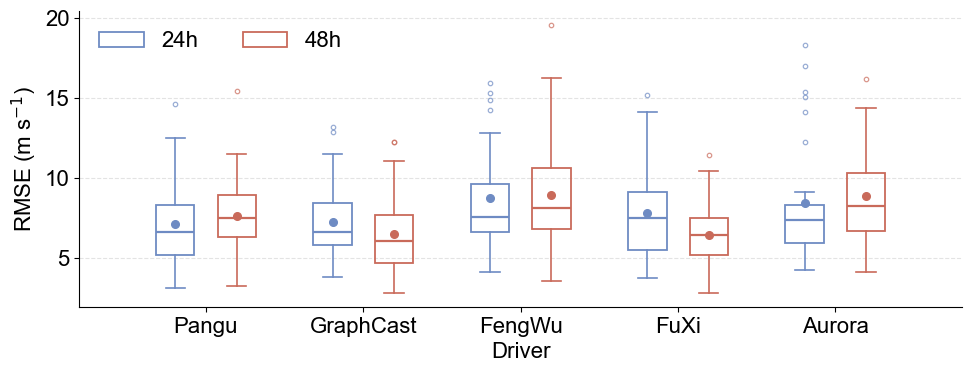

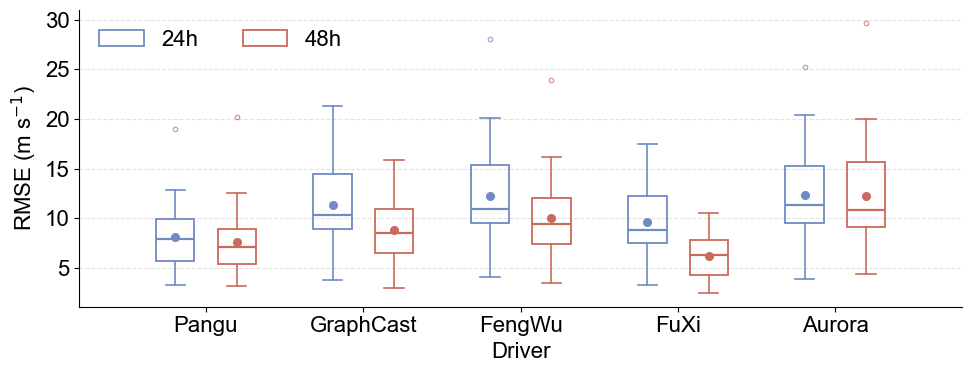

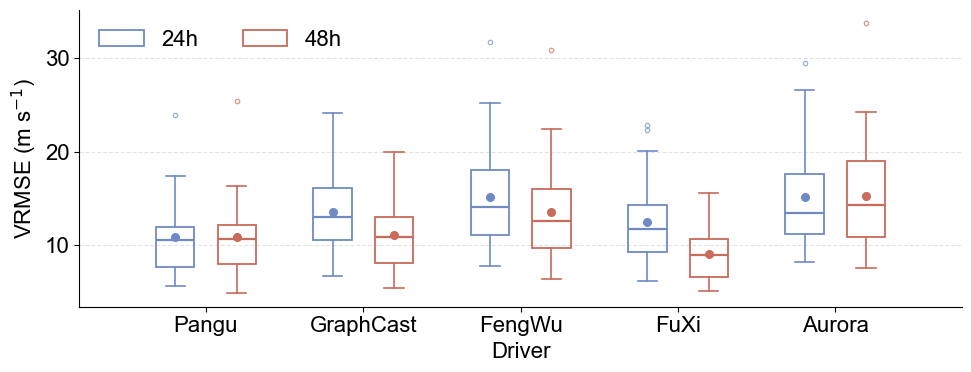

(None,
 None,
 WindowsPath('output/rmse_vector_box_allstations_20250923-10_to_20250924-10.tif'))

In [4]:
# --- Compute RMSE and generate figures ---

# Scalar RMSE (u, v)
u_rmse_long, u_align = compute_scalar_rmse_long(u_obs, u_sim, component="u")
v_rmse_long, v_align = compute_scalar_rmse_long(v_obs, v_sim, component="v")

# Vector RMSE (using both u and v)
vec_rmse_long, vec_align_df = compute_vector_rmse_long(u_obs, v_obs, u_sim, v_sim)

print("Alignment summary (u):")
print(u_align)
print("\nAlignment summary (v):")
print(v_align)
print("\nAlignment summary (vector):")
print(vec_align_df)

print("\nRMSE stats across stations:")
rmse_all = pd.concat([u_rmse_long, v_rmse_long, vec_rmse_long], ignore_index=True)
print(summarize_rmse(rmse_all))

# Figures
out_u = plot_grouped_boxplot(
    u_rmse_long,
    y_label="RMSE (m s$^{-1}$)",
    output_name="rmse_u_box_allstations",
    save=False,
)

out_v = plot_grouped_boxplot(
    v_rmse_long,
    y_label="RMSE (m s$^{-1}$)",
    output_name="rmse_v_box_allstations",
    save=False,
)

out_vec = plot_grouped_boxplot(
    vec_rmse_long,
    y_label="VRMSE (m s$^{-1}$)",
    output_name="rmse_vector_box_allstations",
)

out_u, out_v, out_vec

Yagi window (UTC, inclusive): 2024-09-05 00:00:00+00:00 to 2024-09-06 00:00:00+00:00
Matches Ragasa window duration: 1 days 00:00:00
Yagi stations: 31

Yagi vector alignment summary:
  component lead      model  n_common
0    vector  24h      pangu      1441
1    vector  24h  graphcast      1441
2    vector  24h     fengwu      1441
3    vector  24h       fuxi      1441
4    vector  24h     aurora      1441
5    vector  48h      pangu      1441
6    vector  48h  graphcast      1441
7    vector  48h     fengwu      1441
8    vector  48h       fuxi      1441
9    vector  48h     aurora      1441

Yagi VRMSE stats across stations:
  component      model lead  count       min    median       mean        max
0    vector     aurora  24h     31  4.065792  7.194865   7.789176  13.933386
1    vector     aurora  48h     31  3.955032  8.208113   8.545209  14.712963
2    vector     fengwu  24h     31  4.034201  7.229942   7.714040  13.924884
3    vector     fengwu  48h     31  4.180096  7.697576  

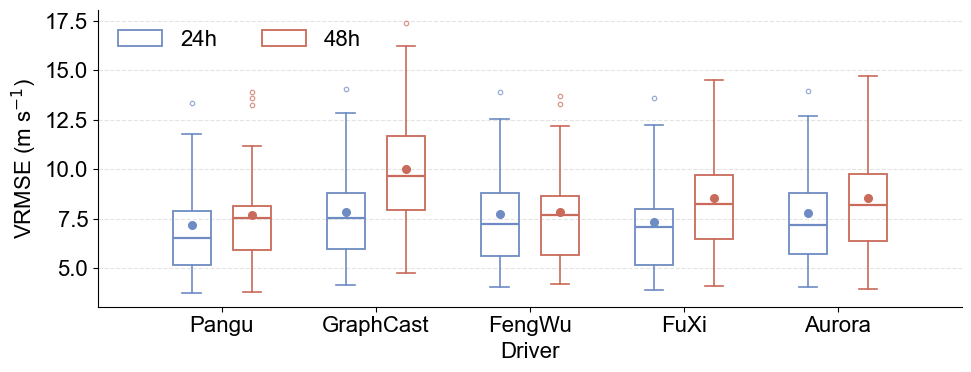

WindowsPath('output/rmse_vector_box_allstations_yagi_20240905-00_to_20240906-00.tif')

In [5]:
# --- Yagi: all-station vector RMSE boxplot from wind speed/direction ---
YAGI_DIR = ROOT_DIR / "input/yagi"
YAGI_MODELS = ["pangu", "graphcast", "fengwu", "fuxi", "aurora"]
YAGI_LEADS = ["24h", "48h"]
YAGI_START_TIME = pd.Timestamp("2024-09-05 00:00", tz="UTC")
YAGI_END_TIME = pd.Timestamp("2024-09-06 00:00", tz="UTC")
YAGI_WINDOW_TAG = f"{YAGI_START_TIME:%Y%m%d-%H}_to_{YAGI_END_TIME:%Y%m%d-%H}"
YAGI_EXPECTED_TIMESTAMPS = 24 * 60 + 1  # inclusive one-minute window

if YAGI_END_TIME - YAGI_START_TIME != END_TIME - START_TIME:
    raise RuntimeError("Yagi and Ragasa VRMSE windows do not have the same duration.")


def read_yagi_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing Yagi input file: {path}")
    return pd.read_csv(path)


def yagi_speed_direction_to_uv(
    speed_raw: pd.DataFrame,
    direction_raw: pd.DataFrame,
    stations: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Convert meteorological wind speed/direction to eastward u and northward v."""
    speed = parse_and_subset(speed_raw, stations, YAGI_START_TIME, YAGI_END_TIME)
    direction = parse_and_subset(direction_raw, stations, YAGI_START_TIME, YAGI_END_TIME)

    if speed[TS_COL].duplicated().any() or direction[TS_COL].duplicated().any():
        raise RuntimeError("Duplicate timestamps found in Yagi wind data.")

    speed = speed.set_index(TS_COL)
    direction = direction.set_index(TS_COL)
    common = speed.index.intersection(direction.index)
    if len(common) == 0:
        raise RuntimeError("No common timestamps between Yagi wind speed and direction.")

    speed_values = speed.loc[common, stations].mask(lambda x: x.eq(32767))
    direction_values = direction.loc[common, stations].mask(lambda x: x.eq(32767))
    direction_rad = np.deg2rad(direction_values)

    # Meteorological direction is where the wind comes from.
    u = -speed_values * np.sin(direction_rad)
    v = -speed_values * np.cos(direction_rad)
    u.index.name = TS_COL
    v.index.name = TS_COL
    return u.reset_index(), v.reset_index()


# Observations
yagi_obs_speed_raw = read_yagi_csv(YAGI_DIR / "results_obs/mean_wspd_obs.csv")
yagi_obs_direction_raw = read_yagi_csv(YAGI_DIR / "results_obs/mean_wdir_obs.csv")

yagi_speed_stations = [c for c in yagi_obs_speed_raw.columns if c != TS_COL]
yagi_direction_stations = [c for c in yagi_obs_direction_raw.columns if c != TS_COL]
if yagi_speed_stations != yagi_direction_stations:
    raise RuntimeError("Yagi observation speed/direction station columns do not match.")
YAGI_STATIONS = yagi_speed_stations

yagi_obs_u, yagi_obs_v = yagi_speed_direction_to_uv(
    yagi_obs_speed_raw, yagi_obs_direction_raw, YAGI_STATIONS
)
yagi_obs_common = set(yagi_obs_u[TS_COL]).intersection(set(yagi_obs_v[TS_COL]))

# Simulations and per-station VRMSE
yagi_records: list[dict] = []
yagi_alignment: list[dict] = []
for lead in YAGI_LEADS:
    for model in YAGI_MODELS:
        speed_path = YAGI_DIR / f"results_sim/{model}_mean_wspd_sim_{lead}.csv"
        direction_path = YAGI_DIR / f"results_sim/{model}_mean_wdir_sim_{lead}.csv"
        sim_speed_raw = read_yagi_csv(speed_path)
        sim_direction_raw = read_yagi_csv(direction_path)
        sim_u, sim_v = yagi_speed_direction_to_uv(
            sim_speed_raw, sim_direction_raw, YAGI_STATIONS
        )

        sim_common = set(sim_u[TS_COL]).intersection(set(sim_v[TS_COL]))
        common = yagi_obs_common.intersection(sim_common)
        yagi_alignment.append(
            {"component": "vector", "lead": lead, "model": model, "n_common": len(common)}
        )

        vrmse = vector_rmse_by_station(
            yagi_obs_u, yagi_obs_v, sim_u, sim_v, YAGI_STATIONS
        )
        yagi_records.extend(
            {
                "component": "vector",
                "lead": lead,
                "model": model,
                "station": station,
                "rmse": float(value) if pd.notna(value) else np.nan,
            }
            for station, value in vrmse.items()
        )

yagi_vec_rmse_long = pd.DataFrame(yagi_records)
yagi_vec_align_df = pd.DataFrame(yagi_alignment)

if not yagi_vec_align_df["n_common"].eq(YAGI_EXPECTED_TIMESTAMPS).all():
    raise RuntimeError("Not all Yagi model/lead combinations have 1441 common timestamps.")
yagi_finite_counts = (
    yagi_vec_rmse_long.dropna(subset=["rmse"])
    .groupby(["model", "lead"])["station"]
    .nunique()
)
if not yagi_finite_counts.eq(len(YAGI_STATIONS)).all():
    raise RuntimeError("At least one Yagi model/lead combination lacks finite VRMSE for a station.")

print("Yagi window (UTC, inclusive):", YAGI_START_TIME, "to", YAGI_END_TIME)
print("Matches Ragasa window duration:", YAGI_END_TIME - YAGI_START_TIME)
print("Yagi stations:", len(YAGI_STATIONS))
print("\nYagi vector alignment summary:")
print(yagi_vec_align_df)
print("\nYagi VRMSE stats across stations:")
print(summarize_rmse(yagi_vec_rmse_long))


def plot_yagi_vector_boxplot(rmse_long: pd.DataFrame):
    """Yagi VRMSE boxplot matching the existing Ragasa publication style."""
    fig, ax = plt.subplots(figsize=(10, 4.0))

    model_spacing = 0.82
    base_positions = np.arange(len(YAGI_MODELS)) * model_spacing
    offset = 0.16
    width = 0.20

    def values_for(model: str, lead: str) -> np.ndarray:
        return (
            rmse_long[(rmse_long["model"] == model) & (rmse_long["lead"] == lead)]["rmse"]
            .astype(float)
            .dropna()
            .values
        )

    data_24h = [values_for(model, "24h") for model in YAGI_MODELS]
    data_48h = [values_for(model, "48h") for model in YAGI_MODELS]

    common_kwargs = dict(
        widths=width,
        patch_artist=True,
        showfliers=True,
        showmeans=True,
        meanline=False,
        boxprops=dict(linewidth=1.3),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        meanprops=dict(
            marker="o", markersize=5.5, markerfacecolor="white",
            markeredgecolor="black", markeredgewidth=1.0,
        ),
        flierprops=dict(
            marker="o", markersize=3.2, markerfacecolor="none",
            markeredgecolor="black", markeredgewidth=0.9, alpha=0.7,
        ),
    )

    bp24 = ax.boxplot(data_24h, positions=base_positions - offset, **common_kwargs)
    bp48 = ax.boxplot(data_48h, positions=base_positions + offset, **common_kwargs)
    color_24h = "#6E8BC3"
    color_48h = "#C96A5A"

    for boxplot, color in ((bp24, color_24h), (bp48, color_48h)):
        for patch in boxplot["boxes"]:
            patch.set_facecolor("none")
            patch.set_edgecolor(color)
            patch.set_linewidth(1.3)
        for whisker in boxplot.get("whiskers", []):
            whisker.set_color(color)
            whisker.set_linewidth(1.2)
        for cap in boxplot.get("caps", []):
            cap.set_color(color)
            cap.set_linewidth(1.2)
        for flier in boxplot.get("fliers", []):
            flier.set_markeredgecolor(color)
        for median in boxplot.get("medians", []):
            median.set_color(color)
            median.set_linewidth(1.6)
        for mean in boxplot.get("means", []):
            mean.set_markerfacecolor(color)
            mean.set_markeredgecolor(color)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([MODEL_STYLES[model]["label"] for model in YAGI_MODELS])
    ax.set_xlabel("Driver")
    ax.set_ylabel("VRMSE (m s$^{-1}$)")
    ax.legend(
        handles=[
            Patch(facecolor="none", edgecolor=color_24h, linewidth=1.3, label="24h"),
            Patch(facecolor="none", edgecolor=color_48h, linewidth=1.3, label="48h"),
        ],
        loc="upper left",
        frameon=False,
        ncol=2,
        fontsize=16,
    )
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    out_path = OUT_DIR / f"rmse_vector_box_allstations_yagi_{YAGI_WINDOW_TAG}.tif"
    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.show()
    return out_path


out_yagi_vec = plot_yagi_vector_boxplot(yagi_vec_rmse_long)
out_yagi_vec

In [6]:
# --- 24h multi-AI mean vs obs: per-station RMSE (wind speed) ---
import cartopy.crs as ccrs
import cartopy.feature as cfeature

LEAD_TO_PLOT = "24h"

# Station metadata (lat/lon)
station_file = ROOT_DIR / "input/ragasa/weather_station_location.xlsx"
station_df = pd.read_excel(station_file, sheet_name="Sheet2")
station_col, lat_col, lon_col = ("pfx", "纬度", "经度")

station_meta = station_df.loc[
    station_df[station_col].isin(STATIONS), [station_col, lat_col, lon_col]
].copy()
station_meta = station_meta.rename(
    columns={station_col: "station", lat_col: "lat", lon_col: "lon"}
).drop_duplicates(subset=["station"])
station_meta[["lat", "lon"]] = station_meta[["lat", "lon"]].apply(pd.to_numeric, errors="coerce")
station_meta = station_meta.dropna(subset=["lat", "lon"]).reset_index(drop=True)

missing_stations = sorted(set(STATIONS) - set(station_meta["station"]))
if missing_stations:
    print(f"Warning: {len(missing_stations)} stations missing lat/lon in {station_file.name}")
    print(missing_stations[:10], "..." if len(missing_stations) > 10 else "")

# Observations (u, v)
obs_u = parse_and_subset(u_obs, STATIONS, START_TIME, END_TIME).set_index(TS_COL)
obs_v = parse_and_subset(v_obs, STATIONS, START_TIME, END_TIME).set_index(TS_COL)


def ensemble_mean_component(sim_by_model: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Ensemble (multi-AI) mean across MODELS for a component (u or v)."""
    model_frames: list[pd.DataFrame] = []
    for model in MODELS:
        sim = parse_and_subset(sim_by_model[model], STATIONS, START_TIME, END_TIME).set_index(TS_COL)
        sim = sim[STATIONS].astype(float)
        sim.columns = pd.MultiIndex.from_product([[model], STATIONS])
        model_frames.append(sim)

    cat = pd.concat(model_frames, axis=1)
    # Average across models for each station; ignore missing values if any
    mean = cat.T.groupby(level=1).mean().T
    mean.index.name = TS_COL
    return mean


u_mean = ensemble_mean_component(u_sim[LEAD_TO_PLOT])
v_mean = ensemble_mean_component(v_sim[LEAD_TO_PLOT])

# Common timestamps for speed computations
common_ts = obs_u.index.intersection(obs_v.index).intersection(u_mean.index).intersection(v_mean.index)
if len(common_ts) == 0:
    raise RuntimeError("No common timestamps between obs and multi-AI mean simulations.")

obs_u_c = obs_u.loc[common_ts, STATIONS]
obs_v_c = obs_v.loc[common_ts, STATIONS]
u_mean_c = u_mean.loc[common_ts, STATIONS]
v_mean_c = v_mean.loc[common_ts, STATIONS]

ws_obs = np.sqrt(obs_u_c**2 + obs_v_c**2)
ws_mean = np.sqrt(u_mean_c**2 + v_mean_c**2)

# RMSE per station (wind speed)
ws_obs_df = ws_obs.reset_index()
ws_mean_df = ws_mean.reset_index()
rmse_ws = rmse_by_station(ws_obs_df, ws_mean_df, STATIONS)

station_stats = (
    station_meta.set_index("station")
    .join(rmse_ws.rename("rmse_24h"))
    .reset_index()
)

print("24h multi-AI mean vs obs (wind speed):")
print("N stations with RMSE:", station_stats["rmse_24h"].notna().sum())
station_stats[["rmse_24h"]].describe()

24h multi-AI mean vs obs (wind speed):
N stations with RMSE: 30


,rmse_24h
count,30.000000
mean,7.740759
std,2.690768
min,3.368152
25%,5.763845
50%,7.548660
75%,9.221668
max,13.271004


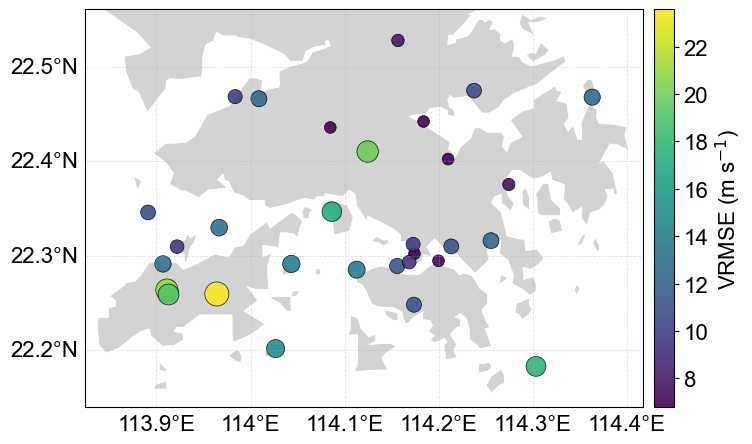

In [7]:
# --- Spatial plot: colormap = Vector RMSE (fixed domain extent) ---

from matplotlib.ticker import MaxNLocator

# Vector RMSE per station for multi-AI mean vs obs: sqrt(mean(du^2 + dv^2))
du = u_mean_c - obs_u_c
dv = v_mean_c - obs_v_c
rmse_vec = np.sqrt((du**2 + dv**2).mean(axis=0, skipna=True))
rmse_vec.name = "vec_rmse"

# Join station metadata with RMSE values
plot_df = (
    station_meta.set_index("station")
    .join(rmse_vec.rename(f"vec_rmse_{LEAD_TO_PLOT}"))
    .reset_index()
    .dropna(subset=["lat", "lon", f"vec_rmse_{LEAD_TO_PLOT}"])
    .copy()
 )

if plot_df.empty:
    raise RuntimeError("No stations available for plotting (missing lat/lon or vector RMSE).")

rmse = plot_df[f"vec_rmse_{LEAD_TO_PLOT}"].to_numpy(dtype=float)

# Marker size scaling (area in points^2)
rmse_max = np.nanmax(rmse)
if not np.isfinite(rmse_max) or rmse_max <= 0:
    raise RuntimeError("Invalid vector RMSE values; cannot scale marker sizes.")

sizes = 30.0 + 270.0 * (rmse / rmse_max) ** 1.5

# Fixed domain extent
lat_min, lat_max, lon_min, lon_max = (22.139, 22.562, 113.824, 114.417)

fig = plt.figure(figsize=(7.2, 6.2))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgray")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white")
# ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
# ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5, alpha=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.35, linestyle="--")
gl.top_labels = False
gl.right_labels = False

# Colormap
cmap_name = "viridis"
try:
    cmap = plt.get_cmap(cmap_name)
except ValueError:
    print(f"Warning: colormap '{cmap_name}' not found; using 'RdYlBu_r' instead.")
    cmap = plt.get_cmap("RdYlBu_r")

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    s=sizes,
    c=rmse,
    cmap=cmap,
    vmin=float(np.nanmin(rmse)),
    vmax=float(np.nanmax(rmse)),
    transform=ccrs.PlateCarree(),
    edgecolor="black",
    linewidth=0.5,
    alpha=0.90,
 )

# Colorbar aligned with the map frame (same height as axes)
cax = ax.inset_axes([1.02, 0.0, 0.035, 1.0], transform=ax.transAxes)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("VRMSE (m s$^{-1}$)")

# Integer-only ticks on the colorbar
cbar.locator = MaxNLocator(integer=True)
cbar.update_ticks()

# Display only; only VRMSE boxplots are written to disk.
plt.show()

out_map = None
out_map